In [1]:
#Step 1: Import Required Libraries
# Data handling

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# NLP preprocessing

import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
#Step 2: Download NLTK Resources
# Download NLP resources

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sagni\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sagni\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
#Step 3: Download Dataset
#SMSSpamCollection, https://archive.ics.uci.edu/dataset/228/sms+spam+collection?utm_source=chatgpt.com

#Step 4: Load Dataset
# Import pandas

import pandas as pd

# Load SMS Spam Collection dataset
# The dataset is tab-separated and contains two columns:
# label (ham/spam) and message

df = pd.read_csv(
    r"C:\Users\sagni\Downloads\sms+spam+collection\SMSSpamCollection",
    sep='\t',
    names=['label', 'message'],
    encoding='latin-1'
)

# Display first 5 rows

print("First 5 Rows:")
print(df.head())

# Display dataset shape

print("\nDataset Shape:")
print(df.shape)

# Display column names

print("\nColumns:")
print(df.columns)

# Check class distribution

print("\nSpam vs Ham Count:")
print(df['label'].value_counts())

First 5 Rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape:
(5572, 2)

Columns:
Index(['label', 'message'], dtype='object')

Spam vs Ham Count:
label
ham     4825
spam     747
Name: count, dtype: int64


(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4825
spam     747
Name: count, dtype: int64


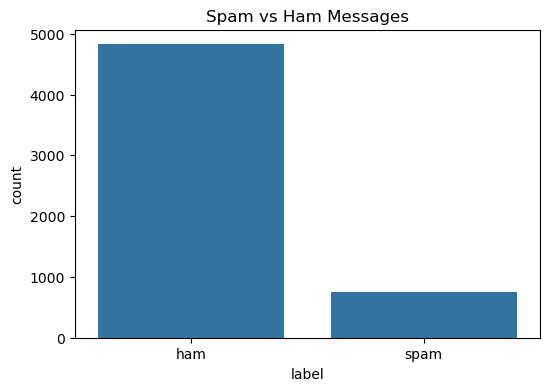

In [7]:
#Step 5: Explore Dataset
# Dataset information

print(df.shape)

print(df.info())

# Class distribution

print(df['label'].value_counts())

#Visualize Spam vs Ham
plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df
)

plt.title("Spam vs Ham Messages")
plt.show()

In [9]:
#Step 6: Convert Labels into Numbers
# Convert labels

df['label_num'] = df['label'].map({
    'ham':0,
    'spam':1
})

print(df.head())

  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


In [13]:
#Step 7: Text Preprocessing
#Create Cleaning Function
# English stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase

    text = text.lower()

    # Remove punctuation

    text = ''.join(
        char for char in text
        if char not in string.punctuation
    )

    # Tokenization

    words = word_tokenize(text)

    # Remove stopwords

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply Cleaning
# # Clean messages

df['clean_message'] = df['message'].apply(clean_text)

print(df[['message','clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


In [15]:
#Step 8: Convert Text to Numeric Features
#Why TF-IDF?
#TF-IDF gives higher importance to meaningful words and lower importance to common words.

# Create vectorizer

tfidf = TfidfVectorizer()

# Convert text to vectors

X = tfidf.fit_transform(
    df['clean_message']
)

# Target

y = df['label_num']

print(X.shape)

(5572, 9455)


In [17]:
#Step 9: Split Data
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4457, 9455)
(1115, 9455)


In [19]:
#Step 10: Train Naive Bayes
# Create model

nb_model = MultinomialNB()

# Train

nb_model.fit(
    X_train,
    y_train
)

# Predict

nb_pred = nb_model.predict(X_test)

In [21]:
#Step 11: Evaluate Naive Bayes
# Accuracy

nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

# Precision

nb_precision = precision_score(
    y_test,
    nb_pred
)

# F1 Score

nb_f1 = f1_score(
    y_test,
    nb_pred
)

print("Naive Bayes Results")

print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("F1 Score:", nb_f1)

print(confusion_matrix(
    y_test,
    nb_pred
))

print(classification_report(
    y_test,
    nb_pred
))

Naive Bayes Results
Accuracy: 0.9614349775784753
Precision: 1.0
F1 Score: 0.8313725490196079
[[966   0]
 [ 43 106]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [23]:
#Step 12: Train Logistic Regression
# Create model

lr_model = LogisticRegression()

# Train

lr_model.fit(
    X_train,
    y_train
)

# Predict

lr_pred = lr_model.predict(X_test)

In [25]:
#Step 13: Evaluate Logistic Regression
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

print("Logistic Regression Results")

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("F1 Score:", lr_f1)

print(confusion_matrix(
    y_test,
    lr_pred
))

print(classification_report(
    y_test,
    lr_pred
))

Logistic Regression Results
Accuracy: 0.9515695067264573
Precision: 1.0
F1 Score: 0.7786885245901639
[[966   0]
 [ 54  95]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       966
           1       1.00      0.64      0.78       149

    accuracy                           0.95      1115
   macro avg       0.97      0.82      0.88      1115
weighted avg       0.95      0.95      0.95      1115



In [27]:
#Step 14: Compare Both Models
results = pd.DataFrame({

    'Model':[
        'Naive Bayes',
        'Logistic Regression'
    ],

    'Accuracy':[
        nb_accuracy,
        lr_accuracy
    ],

    'Precision':[
        nb_precision,
        lr_precision
    ],

    'F1 Score':[
        nb_f1,
        lr_f1
    ]

})

print(results)

                 Model  Accuracy  Precision  F1 Score
0          Naive Bayes  0.961435        1.0  0.831373
1  Logistic Regression  0.951570        1.0  0.778689


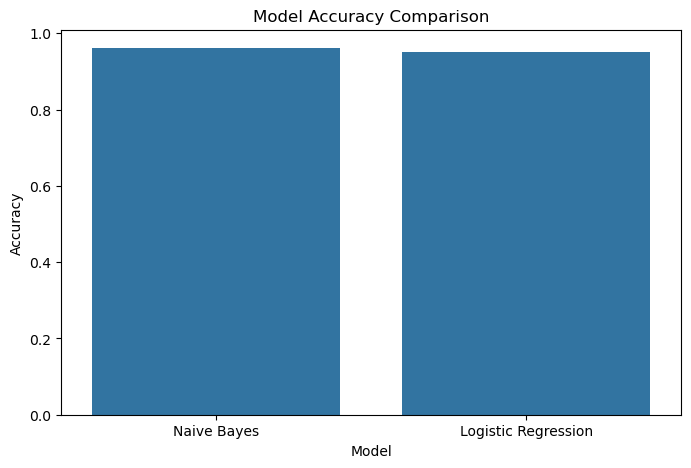

In [29]:
#Step 15: Visual Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")
plt.show()

In [31]:
#Step 16: Select Best Model
best_model = results.loc[
    results['F1 Score'].idxmax()
]

print(best_model)

Model        Naive Bayes
Accuracy        0.961435
Precision            1.0
F1 Score        0.831373
Name: 0, dtype: object
